<a href="https://colab.research.google.com/github/M-marshiro/Fliprobo-Projects/blob/main/homework4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from sklearn.datasets import load_breast_cancer

In [5]:
breast_cancer = load_breast_cancer()

In [6]:
print(breast_cancer.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [7]:
breast_cancer.data.shape

(569, 30)

In [8]:
breast_cancer.target.shape

(569,)

In [9]:
breast_cancer.target_names

array(['malignant', 'benign'], dtype='<U9')

In [10]:
breast_cancer.target[::50]

array([0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1])

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    breast_cancer.data,
    breast_cancer.target,
    random_state=11
)

In [13]:
X_train.shape

(426, 30)

In [14]:
X_test.shape

(143, 30)

In [15]:
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

y_train shape: (426,)
y_test shape: (143,)


In [16]:
from sklearn.naive_bayes import GaussianNB

In [17]:
nb = GaussianNB()

In [18]:
nb.fit(X=X_train, y=y_train)

GaussianNB()

In [19]:
predicted = nb.predict(X=X_test)

In [20]:
expected = y_test

In [21]:
predicted[:20]

array([0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0])

In [22]:
expected[:20]

array([0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0])

In [23]:
wrong = [
    (p, e)
    for (p, e) in zip(predicted, expected)
    if p != e
]

wrong

[(np.int64(1), np.int64(0)),
 (np.int64(1), np.int64(0)),
 (np.int64(0), np.int64(1)),
 (np.int64(1), np.int64(0)),
 (np.int64(1), np.int64(0)),
 (np.int64(1), np.int64(0)),
 (np.int64(1), np.int64(0))]

In [24]:
len(wrong)

7

In [25]:
print(f'{nb.score(X_test, y_test):.2%}')

95.10%


In [26]:
from sklearn.metrics import confusion_matrix

In [27]:
confusion = confusion_matrix(
    y_true=expected,
    y_pred=predicted
)

In [28]:
confusion

array([[44,  6],
       [ 1, 92]])

In [29]:
from sklearn.metrics import classification_report

In [30]:
names = breast_cancer.target_names

In [31]:
print(
    classification_report(
        expected,
        predicted,
        target_names=names
    )
)

              precision    recall  f1-score   support

   malignant       0.98      0.88      0.93        50
      benign       0.94      0.99      0.96        93

    accuracy                           0.95       143
   macro avg       0.96      0.93      0.94       143
weighted avg       0.95      0.95      0.95       143



In [32]:
import pandas as pd

In [33]:
confusion_df = pd.DataFrame(
    confusion,
    index=breast_cancer.target_names,
    columns=breast_cancer.target_names
)

confusion_df

,malignant,benign
malignant,44,6
benign,1,92


In [34]:
import seaborn as sns

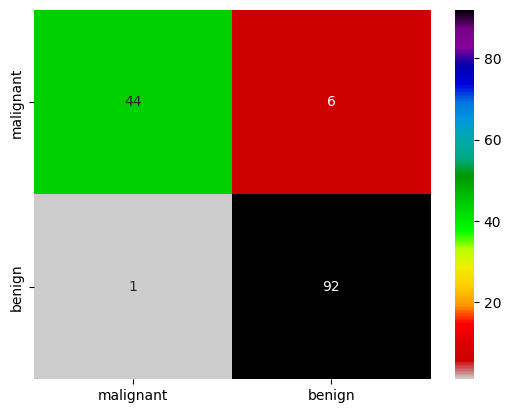

In [35]:
axes = sns.heatmap(
    confusion_df,
    annot=True,
    cmap='nipy_spectral_r'
)

In [36]:
axes.set_title('GaussianNB Confusion Matrix')
axes.set_xlabel('Predicted')
axes.set_ylabel('Expected')

Text(4.444444444444448, 0.5, 'Expected')

In [37]:
from sklearn.model_selection import KFold

In [38]:
kfold = KFold(
    n_splits=10,
    random_state=11,
    shuffle=True
)

In [39]:
from sklearn.model_selection import cross_val_score

In [40]:
scores = cross_val_score(
    estimator=nb,
    X=breast_cancer.data,
    y=breast_cancer.target,
    cv=kfold
)

In [41]:
scores

array([0.96491228, 0.9122807 , 0.94736842, 0.89473684, 0.96491228,
       0.94736842, 0.96491228, 0.89473684, 0.96491228, 0.92857143])

In [42]:
print(f'Mean accuracy: {scores.mean():.2%}')

Mean accuracy: 93.85%


In [43]:
print(f'Accuracy standard deviation: {scores.std():.2%}')

Accuracy standard deviation: 2.75%


In [44]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [45]:
estimators = {
    'GaussianNB': nb,
    'KNeighborsClassifier': KNeighborsClassifier(),
    'LogisticRegression': LogisticRegression(
        solver='lbfgs',
        multi_class='ovr',
        max_iter=10000
    ),
    'SVC': SVC(gamma='scale')
}

In [46]:
estimators

{'GaussianNB': GaussianNB(),
 'KNeighborsClassifier': KNeighborsClassifier(),
 'LogisticRegression': LogisticRegression(max_iter=10000, multi_class='ovr'),
 'SVC': SVC()}

In [47]:
for estimator_name, estimator_object in estimators.items():
    kfold = KFold(
        n_splits=10,
        random_state=11,
        shuffle=True
    )

    scores = cross_val_score(
        estimator=estimator_object,
        X=breast_cancer.data,
        y=breast_cancer.target,
        cv=kfold
    )

    print(
        f'{estimator_name:>20}: '
        f'mean accuracy={scores.mean():.2%}; '
        f'standard deviation={scores.std():.2%}'
    )

          GaussianNB: mean accuracy=93.85%; standard deviation=2.75%
KNeighborsClassifier: mean accuracy=92.79%; standard deviation=2.01%


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was depre

  LogisticRegression: mean accuracy=95.08%; standard deviation=3.02%
                 SVC: mean accuracy=91.92%; standard deviation=3.52%
